
--- 100 K (q6.lead) ---
    Step    Col         Mean          Std
       0 c_boolead[2]     0.395004     0.028599
    1000 c_boolead[2]     0.397929     0.028362
    2000 c_boolead[2]     0.396696     0.029275
    3000 c_boolead[2]     0.397690     0.029155
    4000 c_boolead[2]     0.395151     0.030288
    5000 c_boolead[2]     0.392597     0.031388
    6000 c_boolead[2]     0.391643     0.031114
    7000 c_boolead[2]     0.387836     0.031048
    8000 c_boolead[2]     0.383963     0.032873
    9000 c_boolead[2]     0.379749     0.034199
   10000 c_boolead[2]     0.374661     0.035145
   11000 c_boolead[2]     0.369526     0.035367
   12000 c_boolead[2]     0.362186     0.036703
   13000 c_boolead[2]     0.343394     0.041501
   14000 c_boolead[2]     0.322357     0.047780
   15000 c_boolead[2]     0.308878     0.048561
   16000 c_boolead[2]     0.304329     0.052496
   17000 c_boolead[2]     0.303326     0.054613
   18000 c_boolead[2]     0.300185     0.053180
   19000 c_boolead[2]

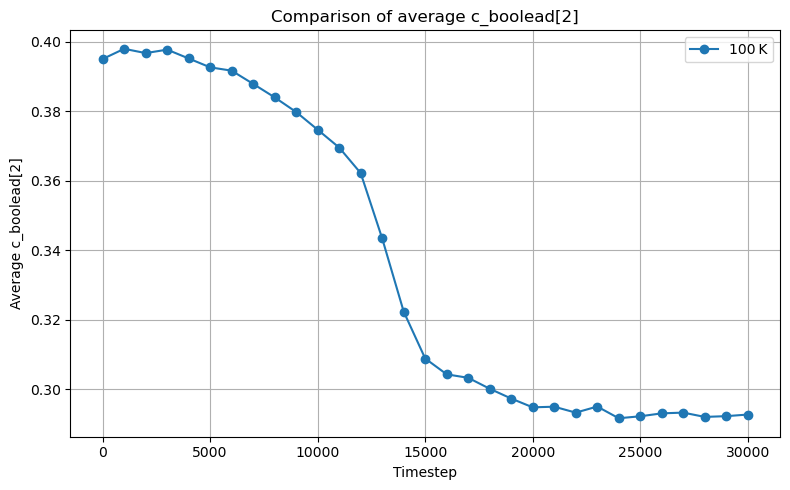

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

def parse_file_per_timestep(filename, column_index):
    
# orientational paramters dictionary
#5 = Q4
#6 = Q6 (used most to detect amorphization)
#7 = Q8
#8 = Q10
#9 = Q12


    results = []
    current_timestep = None
    current_values = []
    reading_atoms = False
    column_name = None
    previous_timestep = None

    with open(filename, 'r') as f:
        for line in f:
            if line.startswith("ITEM: TIMESTEP"):
                # Write previous timestep result
                if current_values and previous_timestep is not None:
                    results.append((previous_timestep, column_name,
                                    np.mean(current_values),
                                    np.std(current_values)))
                    current_values = []
                current_timestep = int(next(f).strip())
                previous_timestep = current_timestep
                reading_atoms = False
                continue

            elif line.startswith("ITEM: ATOMS"):
                headers = line.strip().split()[2:]
                if column_index >= len(headers):
                    raise IndexError("Column index out of range.")
                column_name = headers[column_index]
                reading_atoms = True
                current_values = []
                continue

            elif line.startswith("ITEM:"):
                reading_atoms = False
                continue

            if reading_atoms:
                parts = line.split()
                try:
                    current_values.append(float(parts[column_index]))
                except:
                    pass

    # Write last block if needed
    if current_values and previous_timestep is not None:
        results.append((previous_timestep, column_name,
                        np.mean(current_values),
                        np.std(current_values)))
    return results

def plot_multiple(stats_list, labels):
    """
    Plots average values from multiple stats lists against timestep.
    Each stats list is [(timestep, col_name, mean, std), ...]
    """
    plt.figure(figsize=(8,5))
    for stats, label in zip(stats_list, labels):
        timesteps = [r[0] for r in stats]
        means = [r[2] for r in stats]
        plt.plot(timesteps, means, marker='o', linestyle='-', label=label)
    colname = stats_list[0][0][1] if stats_list else 'Value'
    plt.xlabel('Timestep')
    plt.ylabel(f'Average {colname}')
    plt.title(f'Comparison of average {colname}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Provide file paths and matching labels here
    files = [       
                "q6_file_path"
    ]
    labels = ["300 K"]

    all_stats = []
    for fpath, label in zip(files, labels):
        stats = parse_file_per_timestep(fpath, column_index=6) #Enter parameter here
        
# orientational paramters dictionary
#5 = Q4
#6 = Q6 (used most to detect amorphization)
#7 = Q8
#8 = Q10
#9 = Q12

        all_stats.append(stats)
        print(f"\n--- {label} ({os.path.basename(fpath)}) ---")
        print(f"{'Step':>8} {'Col':>6} {'Mean':>12} {'Std':>12}")
        for t, col, avg, std in stats:
            print(f"{t:8d} {col:>6} {avg:12.6f} {std:12.6f}")

    # Plot the comparison
    plot_multiple(all_stats, labels)
